# Tetra Star Tracker Experiment

This revised notebook uses `catalog.bin`, builds a cached four-star Tetra database, tests identification, and reports FOV/magnitude accuracy.


## Load Catalog


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.star_tracker_core import *

ensure_dirs()
catalog = load_catalog()
print(f"Catalog stars: {len(catalog):,}")
display(catalog.head(10))


Catalog stars: 9,096


,HR_clean,RA_deg,DEC_deg,Vmag,marker_size
0,2491,101.287083,-16.716111,-1.46,53.69496
1,2326,95.987917,-52.695833,-0.72,45.62304
2,5340,213.915417,19.182500,-0.04,38.78496
3,5459,219.899583,-60.835278,-0.01,38.49606
4,7001,279.234583,38.783611,0.03,38.11254
5,1708,79.172500,45.998056,0.08,37.63584
6,1713,78.634583,-8.201667,0.12,37.25664
7,2943,114.825417,5.225000,0.38,34.83864
8,472,24.428750,-57.236667,0.46,34.11096
9,2061,88.792917,7.406944,0.50,33.75000


## Catalog Plot


C:\Users\PC\OneDrive\Documents\code\Star Tracker\outputs\tetra_catalog_map.png


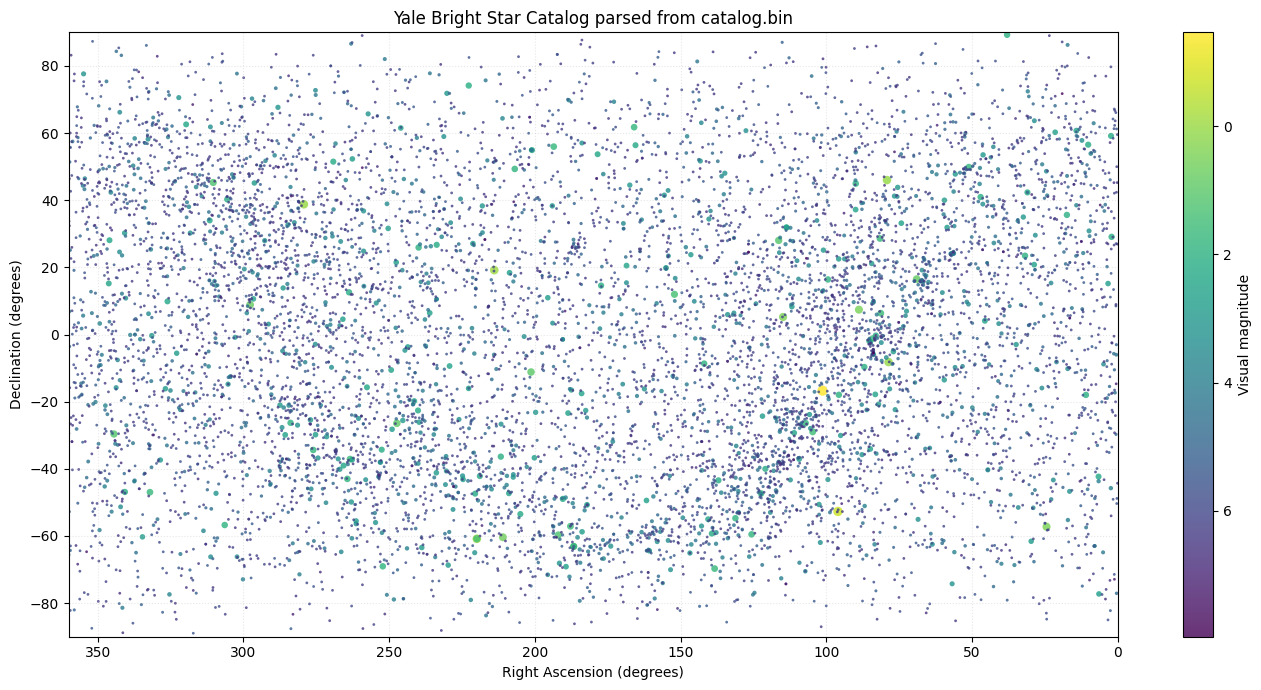

In [2]:
catalog_plot_path = plot_catalog(catalog, "tetra_catalog_map.png")
print(catalog_plot_path)


## Build Database


In [3]:
MAX_STARS_QUERY = 12

tetra_db = build_tetra_database(catalog, fov_deg=8.0, mag_limit=6.5, max_tetras_per_anchor=20)
matcher = TetraMatcher(catalog, tetra_db)
print(f"Tetra database rows: {len(tetra_db):,}")
display(tetra_db.head())


Tetra database rows: 137,143


,hr_a,hr_b,hr_c,hr_d,f1,f2,f3,f4,f5
0,2491,2294,2429,2387,0.438352,0.481426,0.583242,0.743788,0.793612
1,2491,2294,2429,2443,0.192354,0.419097,0.589351,0.647262,0.658474
2,2491,2294,2429,2414,0.484849,0.532492,0.557826,0.822684,0.865459
3,2491,2294,2429,2450,0.532334,0.587989,0.645766,0.934037,0.997689
4,2491,2294,2429,2571,0.424613,0.466337,0.528573,0.535240,0.720476


## Single Identification Test


correct
stars in field: 32
matched HR IDs: [2938, 3003, 3008, 3163]
score: 0.0
C:\Users\PC\OneDrive\Documents\code\Star Tracker\outputs\tetra_single_result.png


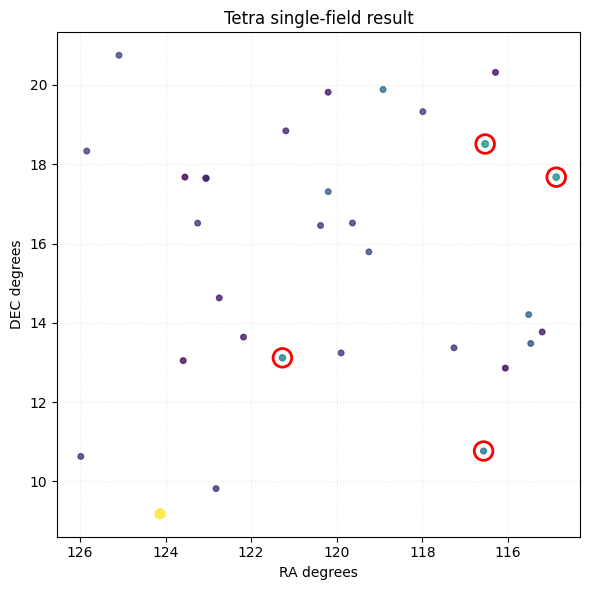

In [4]:
single_result = matcher.identify(
    obs_ra=120.0,
    obs_dec=15.0,
    fov_deg=12.0,
    mag_limit=6.5,
    max_stars_query=MAX_STARS_QUERY,
)
print(single_result["outcome"])
print("stars in field:", single_result["n_stars"])
print("matched HR IDs:", single_result["matched_ids"])
print("score:", single_result["score"])
single_plot_path = plot_single_result(single_result, "tetra_single_result.png", "Tetra single-field result")
print(single_plot_path)


## Batch Identification Test


In [5]:
batch_results = run_batch(
    matcher.identify,
    BatchConfig(samples=20, fov_deg=10.0, mag_limit=6.5, max_stars_query=MAX_STARS_QUERY),
)
batch_summary = summarize_results(batch_results)
display(batch_results.head(10))
batch_summary


,ra,dec,fov_deg,mag_limit,n_stars,outcome,correct,score,mean_residual_deg
0,278.624177,-8.557018,10.0,6.5,23,correct,True,0.000000,NaN
1,309.095251,27.631524,10.0,6.5,22,correct,True,0.000000,NaN
2,33.903845,66.587129,10.0,6.5,8,failure,False,0.006174,NaN
3,274.010293,40.049003,10.0,6.5,14,correct,True,0.000000,NaN
4,46.120908,-6.945969,10.0,6.5,18,correct,True,0.000000,NaN
5,133.487289,59.747098,10.0,6.5,7,failure,False,0.008719,NaN
6,231.791443,45.186626,10.0,6.5,9,correct,True,0.000000,NaN
7,159.629112,-38.186579,10.0,6.5,12,correct,True,0.000000,NaN
8,199.650523,-61.065584,10.0,6.5,17,correct,True,0.000000,NaN
9,297.947222,18.433016,10.0,6.5,31,correct,True,0.000000,NaN


{'total': 80,
 'sparse': 2,
 'valid': 78,
 'correct': 69,
 'failure': 9,
 'accuracy_pct': 88.46153846153845}

## FOV and Magnitude Accuracy Matrix


,FOV,<=5,<=5.5,<=6,<=6.5,ALL
0,8.0,62.500000,60.606061,56.818182,59.649123,59.649123
1,10.0,39.285714,71.739130,72.727273,89.655172,89.655172
2,12.0,51.162791,72.222222,84.745763,93.333333,93.333333
3,15.0,62.264151,87.931034,96.666667,98.333333,98.333333
4,18.0,66.666667,86.666667,91.666667,91.666667,91.666667


,FOV,Magnitude,total,sparse,valid,correct,failure,accuracy_pct
0,8.0,<=5,60,44,16,10,6,62.500000
1,8.0,<=5.5,60,27,33,20,13,60.606061
2,8.0,<=6,60,16,44,25,19,56.818182
3,8.0,<=6.5,60,3,57,34,23,59.649123
4,8.0,ALL,60,3,57,34,23,59.649123
5,10.0,<=5,60,32,28,11,17,39.285714
6,10.0,<=5.5,60,14,46,33,13,71.739130
7,10.0,<=6,60,5,55,40,15,72.727273
8,10.0,<=6.5,60,2,58,52,6,89.655172
9,10.0,ALL,60,2,58,52,6,89.655172


C:\Users\PC\OneDrive\Documents\code\Star Tracker\outputs\tetra_confusion_matrix.png


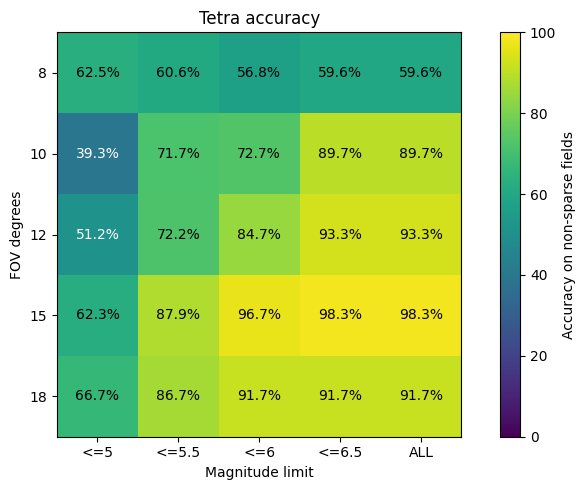

In [6]:
FOV_VALUES = [8.0, 12.0, 18.0]
MAG_LIMITS = [5.0, 6.0, 6.5, None]
MATRIX_SAMPLES = 8

confusion_df, summary_df = run_confusion_matrix(
    matcher.identify,
    fov_values=FOV_VALUES,
    mag_limits=MAG_LIMITS,
    samples=MATRIX_SAMPLES,
    max_stars_query=MAX_STARS_QUERY,
)
confusion_path = plot_confusion_matrix(confusion_df, "Tetra accuracy", "tetra_confusion_matrix.png")

display(confusion_df)
display(summary_df)
print(confusion_path)


## Findings


In [7]:
report = findings(summary_df)
print(report)


Best accuracy: 98.33% at FOV=15.0 deg, magnitude=ALL.
Lowest non-sparse accuracy: 39.29% at FOV=10.0 deg, magnitude=<=5.
Most sparse setting: FOV=8.0 deg, magnitude=<=5 with 44/60 sparse samples.
Accuracy improves when the field has enough bright stars and drops when the query becomes either sparse or too ambiguous.
